# Hands-on: Multiclass Steel Defect Classification

## **Local Environment Setup**

**If you are running this notebook locally**, first create a virtual environment and install the required libraries.

```bash
python -m venv workshop-env
source workshop-env/bin/activate
python -m pip install --upgrade pip
pip install torch torchvision torchaudio pandas matplotlib scikit-learn seaborn torchsummary
```

**If you are using the LUMI notebook environment, simply select the `Python 3` kernel and run the cells.**

In [1]:
import os
import sys
print(sys.executable)

/usr/bin/python3


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import datasets, models
from torchinfo import summary

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Set device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Read information about each library. help(models), models?,  print(models.__doc__), models(shift+tab)

Using device: cuda


# Dataset Setup: Severstal Defect Dataset

We use the `Severstal: Steel Defect Detection` dataset, containing 200 images each of 4 defect types:
- **Scratches**: Surface scratches and abrasions
- **Inclusions**: Foreign particles embedded in steel
- **Patches**: Localized surface irregularities  
- **Rolls Marks**: Marks from the rolling process

Directory structure:
```
single_class_sampled/
├── Scratches/      
├── Inclusions/     
├── Patches/         
└── Rolls Marks/    
```

In [3]:
# Define path to dataset
dataset_path = r"/projappl/project_465002387/DEEP_Inspection_Material_Science/data/single_class_sampled"

if not os.path.exists(dataset_path):
    print(f"Error: {dataset_path} folder not found!")
else:
    print(f"Dataset path: {os.path.abspath(dataset_path)}")

Dataset path: /pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/data/single_class_sampled


In [4]:
# Get sorted class names
class_names = sorted(os.listdir(dataset_path))
print(f"Classes found: {class_names}")
print(f"Number of classes: {len(class_names)}")

# Count images per class
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    num_images = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{class_name}: {num_images} images")

Classes found: ['Inclusions', 'Patches', 'Rolls Marks', 'Scratches']
Number of classes: 4
Inclusions: 195 images
Patches: 500 images
Rolls Marks: 500 images
Scratches: 500 images


In [5]:
# Load dataset in batches
BATCH_SIZE = 32
IMAGE_SIZE = 255

# PyTorch transforms (normalize with ImageNet stats for transfer learning)
base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=dataset_path,
                                    transform=base_transform)

# Extract all images and labels as arrays for splitting
all_indices = list(range(len(full_dataset)))
all_labels  = [full_dataset.targets[i] for i in all_indices]

# First split: 70% train, 30% holdout (val + test)
train_idx, holdout_idx = train_test_split(
    all_indices, test_size=0.3, random_state=0, stratify=all_labels
)

holdout_labels = [all_labels[i] for i in holdout_idx]

# Second split: 15% val, 15% test
val_idx, test_idx = train_test_split(
    holdout_idx, test_size=0.5, random_state=0, stratify=holdout_labels
)

# Subset samplers
from torch.utils.data import Subset
train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)
test_dataset  = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Total images:       {len(full_dataset)}")
print(f"Training samples:   {len(train_dataset)} ({len(train_dataset)/len(full_dataset)*100:.1f}%)")
print(f"Validation samples: {len(val_dataset)}   ({len(val_dataset)/len(full_dataset)*100:.1f}%)")
print(f"Test samples:       {len(test_dataset)}   ({len(test_dataset)/len(full_dataset)*100:.1f}%)")


Total images:       1695
Training samples:   1186 (70.0%)
Validation samples: 254   (15.0%)
Test samples:       255   (15.0%)


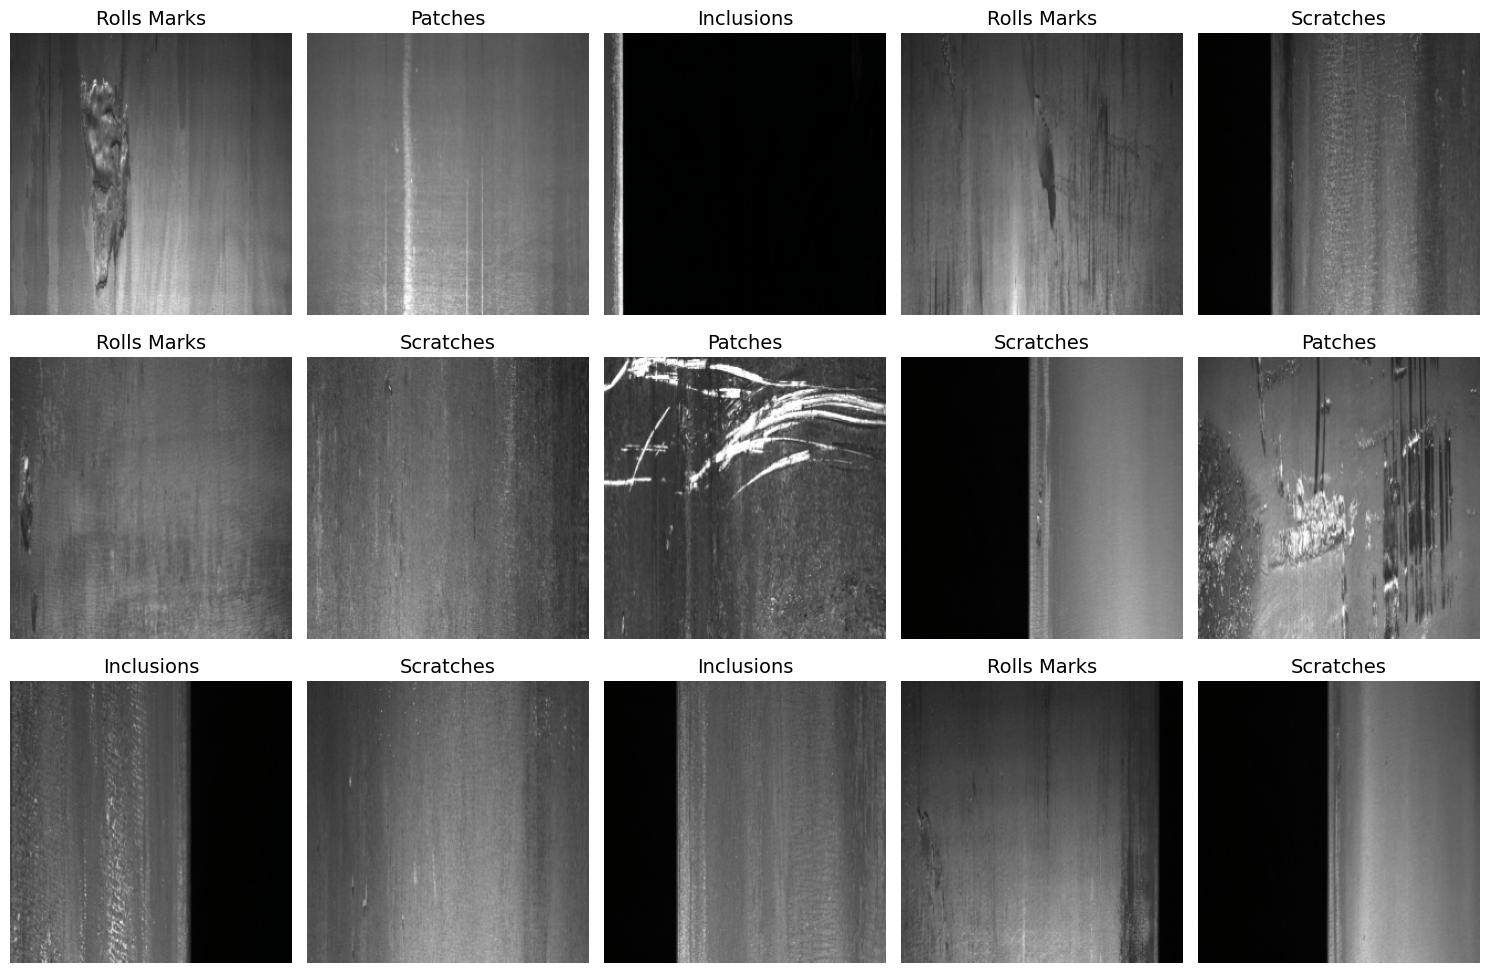

In [6]:
# Visualize sample images from training set
# (un-normalize for display)
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

plt.figure(figsize=(15, 10))
images_batch, labels_batch = next(iter(train_loader))
for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels_batch[i].item()], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()


# Data Augmentation

In [7]:
augment_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.10)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

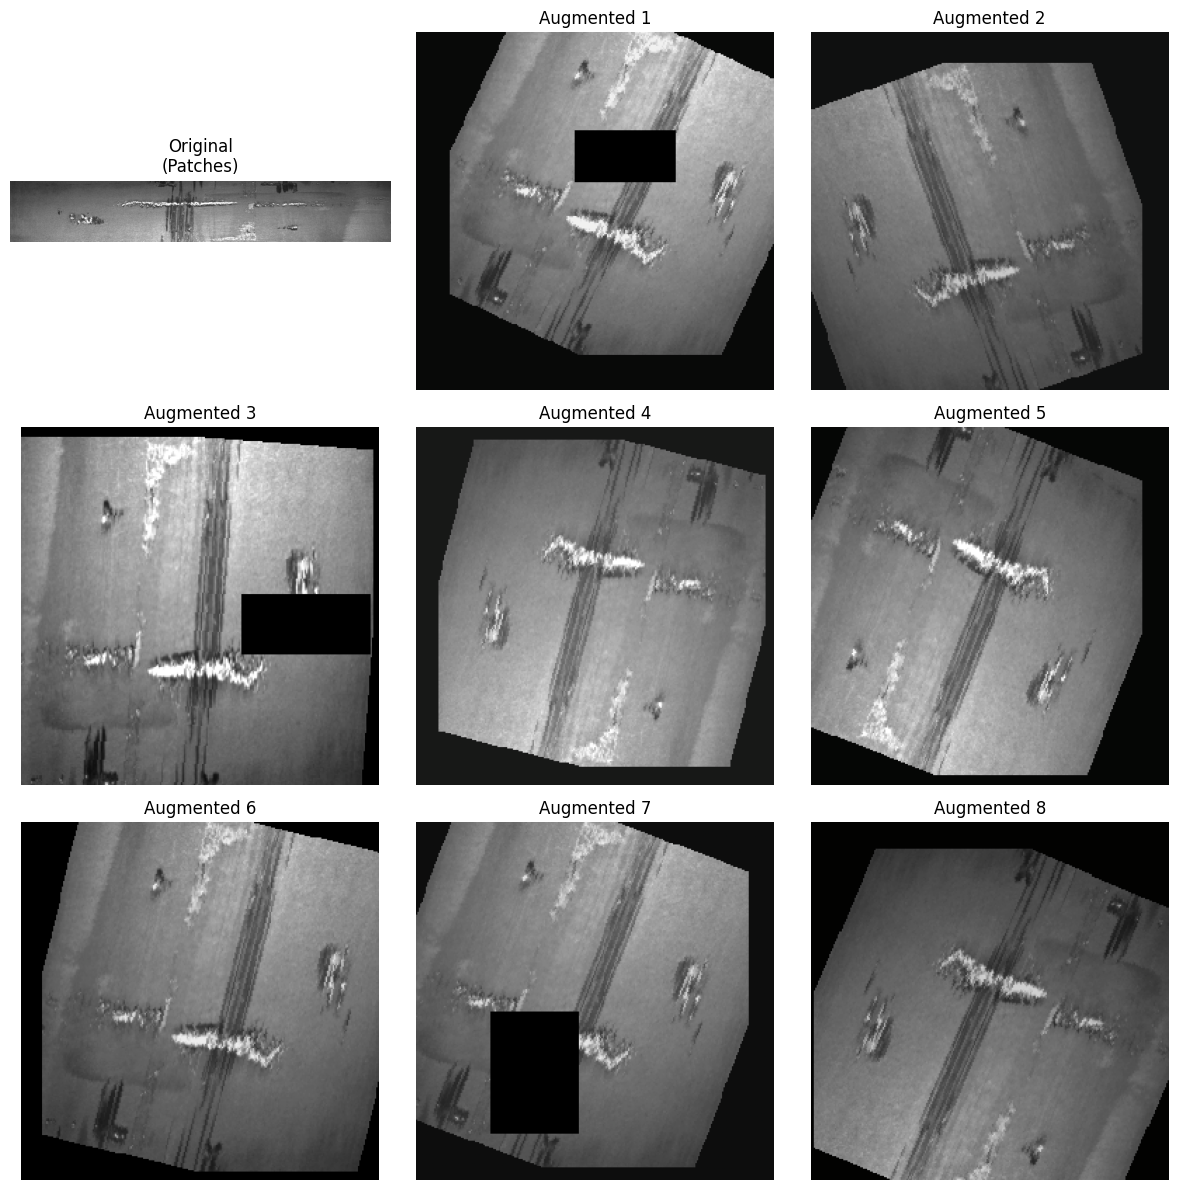

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

sample_dataset_index = train_dataset.indices[0]
sample_path, sample_label = full_dataset.samples[sample_dataset_index]
pil_img = Image.open(sample_path).convert("RGB")


inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

images = [pil_img] + [augment_transform(pil_img) for _ in range(8)]
titles = [f"Original\n({class_names[sample_label]})"] + [f"Augmented {i}" for i in range(1, 9)]

for ax, image, title in zip(axes, images, titles):
    if isinstance(image, torch.Tensor):
        image = inv_normalize(image).permute(1, 2, 0).numpy()
        image = np.clip(image, 0, 1)
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# --- Apply augmentation to the training dataset -----
from torch.utils.data import Subset, ConcatDataset

def augment_dataset(dataset, multiplier):
    # Recover the original ImageFolder root and this subset's indices
    root = dataset.dataset.root
    indices = dataset.indices

    # Augmented "view" of the same folder, same samples, new transform
    augmented_base = datasets.ImageFolder(root=root, transform=augment_transform)
    augmented_subset = Subset(augmented_base, indices)

    return ConcatDataset([augmented_subset] * multiplier)


# Reassign the training loader (val/test loaders unchanged)
AUG_MULTIPLIER = 4
train_dataset2 = augment_dataset(train_dataset, multiplier=AUG_MULTIPLIER)
train_loader = DataLoader(train_dataset2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f"Training samples: {len(train_dataset2)} ({AUG_MULTIPLIER}x, on-the-fly augmentation)")
print(f"Validation samples: {len(val_dataset)}  ")
print(f"Test samples:       {len(test_dataset)} ")

Training samples: 4744 (4x, on-the-fly augmentation)
Validation samples: 254  
Test samples:       255 


# Assignment: Original vs Customized LeNet Models
In this exercise, you will compare the performance of the **original LeNet-5** model with a **customized LeNet** model.

## Tasks

### 1. Train the Original LeNet-5
- Train the model on the given dataset.
- Report:
  - Training/validation loss
  - Training/validation accuracy
  - Test accuracy

### 2. Build a Customized LeNet
Modify the original architecture by replacing:

| Original | Customized |
|---|---|
| `nn.LazyConv2d`, `nn.LazyLinear` | `nn.Conv2d`, `nn.Linear` |
| Average Pooling | Max Pooling |
| Sigmoid | ReLU |
| Xavier weight initialization | PyTorch default initialization |


For read about **weight initialization in neural networks**, including **Xavier (Glorot) Initialization** and **He Initialization** use this article:

🔗 [Weight Initialization in Neural Networks: Xavier and He Initialization](https://medium.com/@tippareddybhargavi0414/weight-initialization-in-neural-networks-482ef5159b98)


### 3. Compare the Models
Compare both models based on:
- Architecture and parameters
- Training performance
- Validation and test accuracy

Briefly discuss the differences in performance.

In [ ]:
def init_cnn(module):
    """Xavier initialization for Conv2d and Linear layers."""
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)

class LeNetOriginal(nn.Module):
    def __init__(self, num_classes=4):
        super(LeNetOriginal, self).__init__()

        self.conv1 = nn.LazyConv2d(6, kernel_size=5, padding=2)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.LazyConv2d(16, kernel_size=5, padding=0)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.LazyLinear(120)
        self.fc2 = nn.LazyLinear(84)
        self.fc3 = nn.LazyLinear(num_classes)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.conv1(x))
        x = self.pool1(x)

        x = self.sigmoid(self.conv2(x))
        x = self.pool2(x)

        x = x.flatten(1)

        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        x = self.fc3(x)

        return x


model_original = LeNetOriginal(num_classes=len(class_names)).to(device)
summary(model_original, input_size=(BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE),depth=10, 
        col_names=["input_size", "output_size", "kernel_size", "num_params"])


# Conv2D output size formula: Output = ((n - f + 2p) / s + 1, (n - f + 2p) / s + 1, out_channels)
# Parameters = (f * f * output_channels) + output_channels (bias)


# Memory (VRAM/RAM) required:
# Input data load: batch_size × channels × height × width × 4 bytes (float32)
# Model Training:  forward/backward propagation (activations + gradients)
# Model Inference: Model total parameters × 4 bytes (float32)

# Solution for customized LeNet architecture

In [13]:
# Define LeNet model in PyTorch
class LeNet(nn.Module):
    def __init__(self, num_classes=4):
        super(LeNet, self).__init__()
        
        # First convolutional layer
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Second convolutional layer
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(16 * 60 * 60, 120)  # if you dont know how to set: self.fc1 = nn.LazyLinear(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

# Create model
model_lenet = LeNet(num_classes=len(class_names)).to(device)
print(f"Input shape: [{BATCH_SIZE}, 3, {IMAGE_SIZE}, {IMAGE_SIZE}]")
from torchinfo import summary

summary(
    model_lenet,
    input_size=(BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE),
    depth=10,
    col_names=["input_size", "output_size", "kernel_size", "num_params"])

Input shape: [32, 3, 255, 255]


Layer (type:depth-idx)                   Input Shape               Output Shape              Kernel Shape              Param #
LeNet                                    [32, 3, 255, 255]         [32, 4]                   --                        --
├─Conv2d: 1-1                            [32, 3, 255, 255]         [32, 6, 251, 251]         [5, 5]                    456
├─ReLU: 1-2                              [32, 6, 251, 251]         [32, 6, 251, 251]         --                        --
├─MaxPool2d: 1-3                         [32, 6, 251, 251]         [32, 6, 125, 125]         2                         --
├─Conv2d: 1-4                            [32, 6, 125, 125]         [32, 16, 121, 121]        [5, 5]                    2,416
├─ReLU: 1-5                              [32, 16, 121, 121]        [32, 16, 121, 121]        --                        --
├─MaxPool2d: 1-6                         [32, 16, 121, 121]        [32, 16, 60, 60]          2                         --
├─Linear: 1-7  

In [14]:
# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss, accuracy

# Validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy

In [ ]:
# Training parameters
EPOCHS = 7
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lenet.parameters(), lr=0.001)

# Training loop
history = {
    'loss': [],
    'val_loss': [],
    'accuracy': [],
    'val_accuracy': []
}

# Start timer
start_time = time.time()

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model_lenet, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model_lenet, val_loader, criterion, device)
    
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


# Training time
end_time = time.time()
print(f"\nTotal training time: {(end_time-start_time):.2f} seconds")
print(f"Average time per epoch: {(end_time-start_time)/EPOCHS:.2f} seconds")

Epoch 1/7 - Loss: 0.9758, Acc: 0.5569, Val Loss: 0.8092, Val Acc: 0.6654
Epoch 2/7 - Loss: 0.9432, Acc: 0.5913, Val Loss: 0.8546, Val Acc: 0.6811
Epoch 3/7 - Loss: 0.9115, Acc: 0.6039, Val Loss: 0.8300, Val Acc: 0.6890
Epoch 4/7 - Loss: 0.8708, Acc: 0.6320, Val Loss: 0.9520, Val Acc: 0.6024
Epoch 5/7 - Loss: 0.8484, Acc: 0.6265, Val Loss: 0.7460, Val Acc: 0.7165
Epoch 6/7 - Loss: 0.8306, Acc: 0.6505, Val Loss: 0.6828, Val Acc: 0.7559
Epoch 7/7 - Loss: 0.7972, Acc: 0.6747, Val Loss: 0.6558, Val Acc: 0.7362

Total training time: 269.89 seconds
Average time per epoch: 38.56 seconds


In [51]:
# Save the model
torch.save(model_lenet.state_dict(), 'lenet_model.pth')
print("Model saved as lenet_model.pth")

Model saved as lenet_model.pth


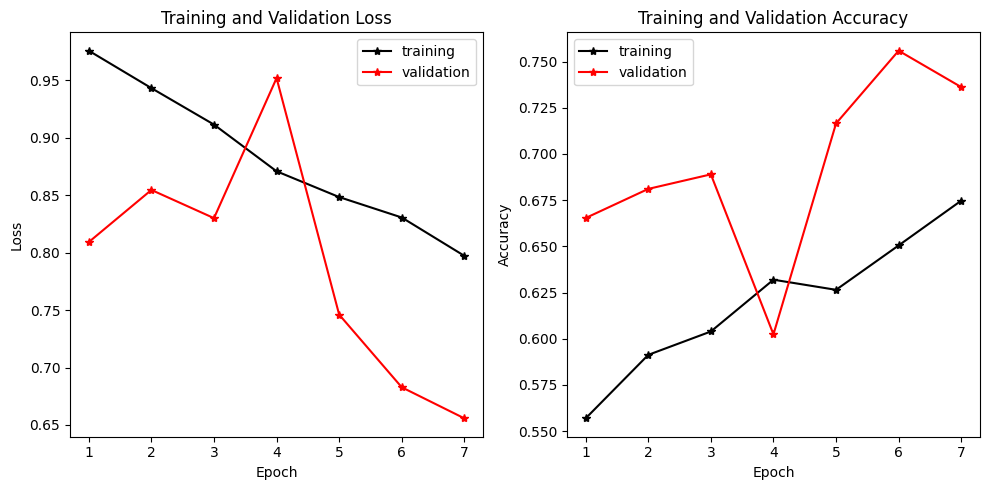

In [17]:
# Plot training history - Loss and Accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(np.arange(1, EPOCHS+1), history['loss'], color='black', label='training', marker='*')
plt.plot(np.arange(1, EPOCHS+1), history['val_loss'], color='red', label='validation', marker='*')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(np.arange(1, EPOCHS+1), history['accuracy'], color='black', label='training', marker='*')
plt.plot(np.arange(1, EPOCHS+1), history['val_accuracy'], color='red', label='validation', marker='*')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.show()

# Model Evaluation

After training the model, we evaluate its performance using different classification metrics.

The **confusion matrix** provides a detailed view of the model predictions by comparing the **actual classes** with the **predicted classes**. It helps identify correctly classified samples and classification errors between different defect categories.

![Confusion Matrix and Related Performance Measures](../episodes/Fig/02_hansdon_confusion_matrix_metrics.png)

*Figure adapted from Rothe et al., DOI: 10.1007/s00521-014-1685-1.*



The following performance measures are derived from the confusion matrix:

- **Accuracy**: How often the model gives the correct prediction overall.
- **Precision**: When the model says "this is a defect type X", how often is it correct? (avoids false alarms, Focuses on **predicted by the model**) 
- **Recall (Detection Rate)**: Of all actual defect type X samples, how many did the model find? (avoids missed defects, Focuses on  **actual samples** ). In quality control, recall is often especially important because missing a defect can cause production problems.
- **F1-score**: A single score that balances correct detections and false alarms.

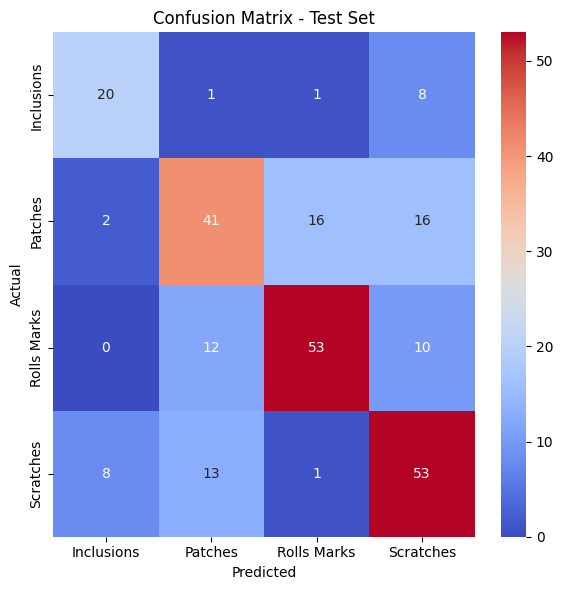


Classification Report - Test Set:
              precision    recall  f1-score   support

  Inclusions       0.67      0.67      0.67        30
     Patches       0.61      0.55      0.58        75
 Rolls Marks       0.75      0.71      0.73        75
   Scratches       0.61      0.71      0.65        75

    accuracy                           0.65       255
   macro avg       0.66      0.66      0.66       255
weighted avg       0.66      0.65      0.65       255



In [18]:
#compute the confusion matrix and classification report for test dataset
# If you want to inference the model from the saved model:
# model_lenet = torch.load("lenet_full_model.pth", map_location=device)
# model_lenet.to(device)
# model_lenet.eval()

model_lenet.eval()
ypred_tot = []
label_tot = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_lenet(images)
        _, predicted = torch.max(outputs, 1)
        ypred_tot.extend(predicted.cpu().numpy())
        label_tot.extend(labels.numpy())

# Create confusion matrix
cm = confusion_matrix(label_tot, ypred_tot)

# Display confusion matrix as heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, cmap="coolwarm", xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report - Test Set:")
print(classification_report(label_tot, ypred_tot, labels=range(len(class_names)), target_names=class_names))

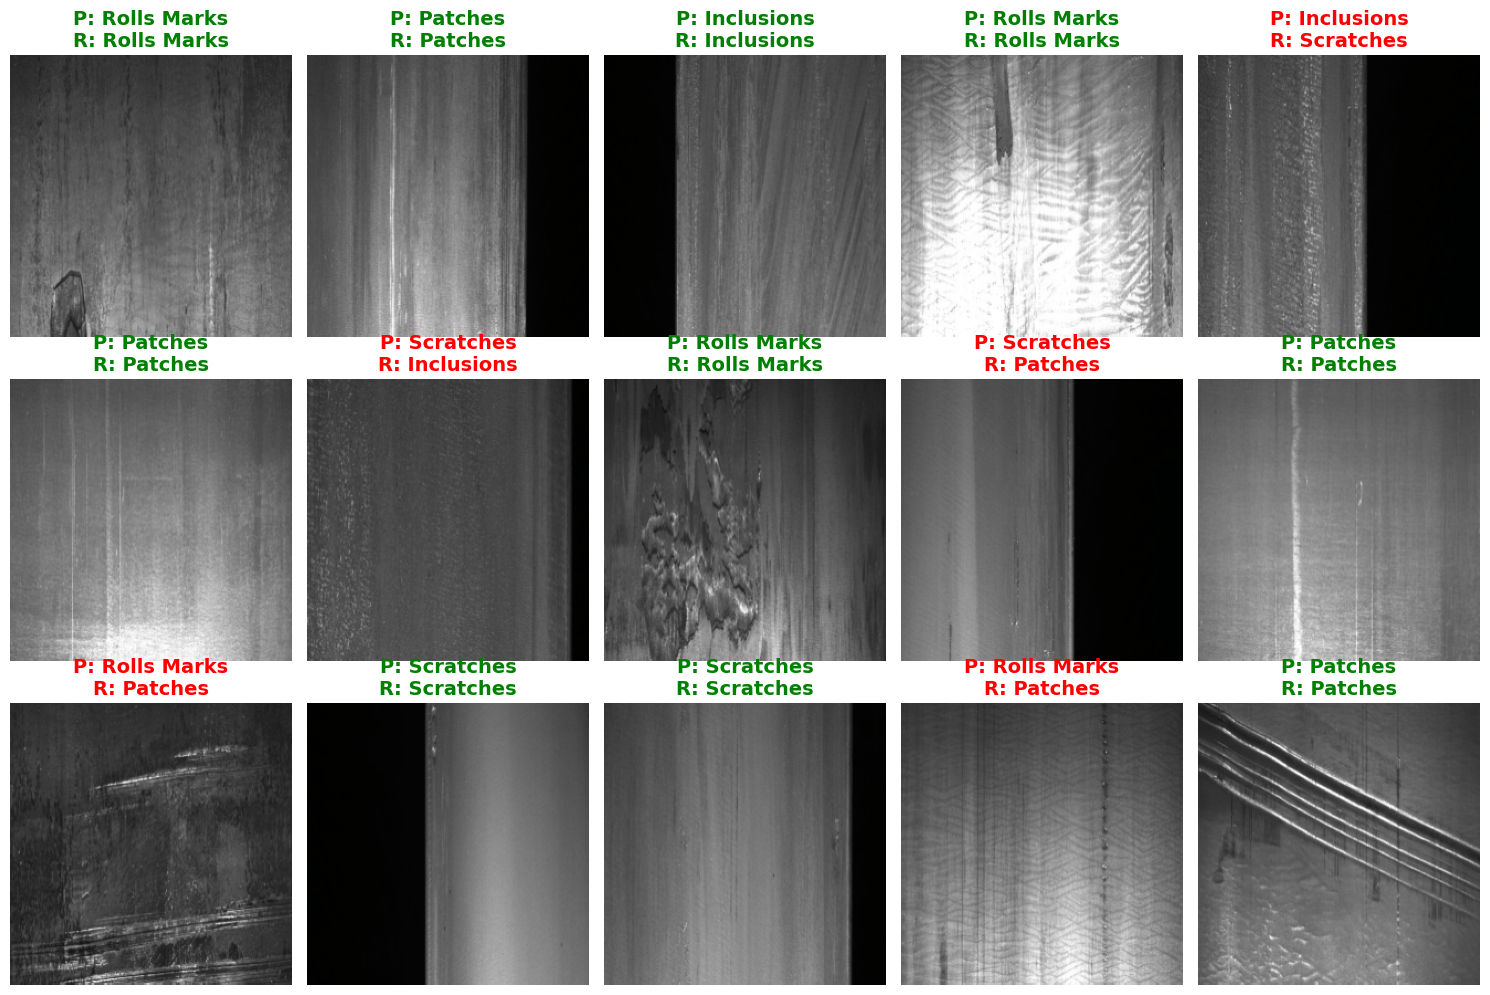


EVALUATING ON TEST SET
Test Loss: 0.7964
Test Accuracy: 0.6549 (65.49%)


In [19]:
# Visualize predictions on test set
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

plt.figure(figsize=(15, 10))
model_lenet.eval()

with torch.no_grad():
    images_batch, labels_batch = next(iter(test_loader))
    outputs = model_lenet(images_batch.to(device))
    _, ypred = torch.max(outputs, 1)

    for i in range(min(15, len(images_batch))):
        ax = plt.subplot(3, 5, i + 1)
        img = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        plt.imshow(img)

        actual_class = labels_batch[i].item()
        pred_class = ypred[i].item()
        color = 'green' if actual_class == pred_class else 'red'
        plt.title(
            f"P: {class_names[pred_class]}\nR: {class_names[actual_class]}",
            color=color,
            fontweight='bold',
            fontsize=14
        )
        plt.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EVALUATING ON TEST SET")
test_loss, test_acc = validate(model_lenet, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Assignment: Applying and Customizing AlexNet

In this assignment, you will apply the **AlexNet architecture** to the given dataset and investigate how architectural changes affect model performance.

## Tasks

1. **Train the AlexNet model** on the dataset and evaluate its performance.

2. **Customize the model architecture** by modifying:
   - Number of convolutional filters (`c1`–`c5`)
   - Fully connected layer sizes  (`fc1`, `fc2`)
   - Dropout rate

3. **Analyze the results**:
   - Compare model performance with different configurations.
   - Explain how these changes affect accuracy, training behavior, and generalization.
   - Discuss how AlexNet can be adapted for a specific dataset.

# Solution for customized AlexNet architecture

In [23]:
class CustomAlexNet(nn.Module):
    def __init__(
        self,
        num_classes=4,
        c1=96,
        c2=256,
        c3=384,
        c4=384,
        c5=256,
        fc1=1024,
        fc2=512,
        dropout=0.5
    ):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=11, stride=4, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(c1, c2, kernel_size=5, padding=2),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(c2, c3, kernel_size=3, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(inplace=True),

            nn.Conv2d(c3, c4, kernel_size=3, padding=1),
            nn.BatchNorm2d(c4),
            nn.ReLU(inplace=True),

            nn.Conv2d(c4, c5, kernel_size=3, padding=1),
            nn.BatchNorm2d(c5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((6, 6)),
            nn.Flatten(),

            nn.Linear(c5 * 6 * 6, fc1),
            nn.BatchNorm1d(fc1),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc1, fc2),
            nn.BatchNorm1d(fc2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc2, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_custom = CustomAlexNet(num_classes=len(class_names)).to(device)
summary(model_custom, input_size=(BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE),depth=10, 
        col_names=["input_size", "output_size", "kernel_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Kernel Shape              Param #
CustomAlexNet                            [32, 3, 255, 255]         [32, 4]                   --                        --
├─Sequential: 1-1                        [32, 3, 255, 255]         [32, 256, 6, 6]           --                        --
│    └─Conv2d: 2-1                       [32, 3, 255, 255]         [32, 96, 62, 62]          [11, 11]                  34,944
│    └─BatchNorm2d: 2-2                  [32, 96, 62, 62]          [32, 96, 62, 62]          --                        192
│    └─ReLU: 2-3                         [32, 96, 62, 62]          [32, 96, 62, 62]          --                        --
│    └─MaxPool2d: 2-4                    [32, 96, 62, 62]          [32, 96, 30, 30]          3                         --
│    └─Conv2d: 2-5                       [32, 96, 30, 30]          [32, 256, 30, 30]         [5, 5]                    614,656
│    └─Ba

In [25]:
# Training parameters for custom model
import time

EPOCHS = 7
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_custom.parameters(), lr=0.001)

# Training loop
history_custom = {
    'loss': [],
    'val_loss': [],
    'accuracy': [],
    'val_accuracy': []
}

start_time = time.time()
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model_custom, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model_custom, val_loader, criterion, device)
    
    history_custom['loss'].append(train_loss)
    history_custom['val_loss'].append(val_loss)
    history_custom['accuracy'].append(train_acc)
    history_custom['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Training time
end_time = time.time()
print(f"\nTotal training time: {(end_time-start_time):.2f} seconds")
print(f"Average time per epoch: {(end_time-start_time)/EPOCHS:.2f} seconds")

Epoch 1/7 - Loss: 1.1356, Acc: 0.4654, Val Loss: 0.9434, Val Acc: 0.5669
Epoch 2/7 - Loss: 0.9945, Acc: 0.5575, Val Loss: 0.9210, Val Acc: 0.5394
Epoch 3/7 - Loss: 0.9678, Acc: 0.5729, Val Loss: 0.7830, Val Acc: 0.6929
Epoch 4/7 - Loss: 0.9196, Acc: 0.6031, Val Loss: 0.7833, Val Acc: 0.6732
Epoch 5/7 - Loss: 0.8756, Acc: 0.6267, Val Loss: 0.7084, Val Acc: 0.7244
Epoch 6/7 - Loss: 0.8691, Acc: 0.6364, Val Loss: 0.9182, Val Acc: 0.6142
Epoch 7/7 - Loss: 0.8330, Acc: 0.6516, Val Loss: 0.6951, Val Acc: 0.7047

Total training time: 276.83 seconds
Average time per epoch: 39.55 seconds


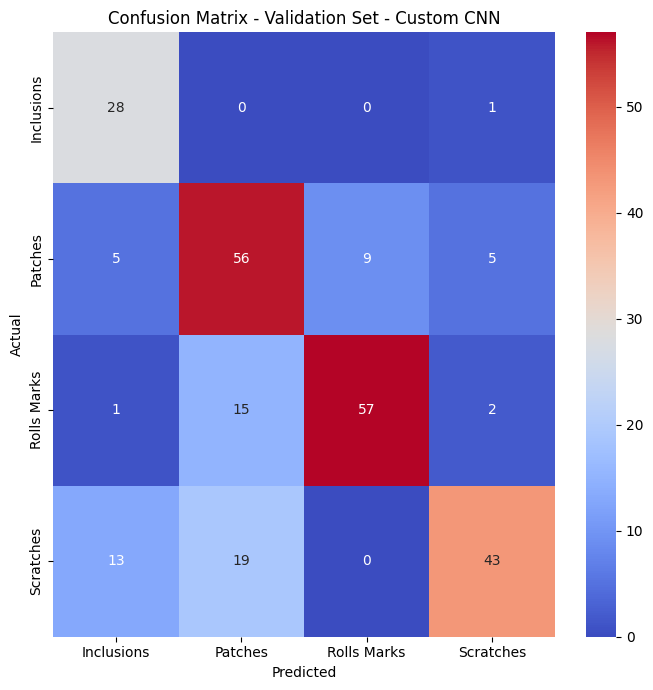


Classification Report - Custom CNN:
              precision    recall  f1-score   support

  Inclusions       0.60      0.97      0.74        29
     Patches       0.62      0.75      0.68        75
 Rolls Marks       0.86      0.76      0.81        75
   Scratches       0.84      0.57      0.68        75

    accuracy                           0.72       254
   macro avg       0.73      0.76      0.73       254
weighted avg       0.76      0.72      0.72       254



In [54]:
# Compute confusion matrix and classification report on validation data for custom model
model_custom.eval()
ypred_tot = []
label_tot = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_custom(images)
        _, predicted = torch.max(outputs, 1)
        ypred_tot.extend(predicted.cpu().numpy())
        label_tot.extend(labels.numpy())

# Create confusion matrix
cm = confusion_matrix(label_tot, ypred_tot)

# Display confusion matrix as heatmap
plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, cmap="coolwarm", xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Validation Set - Custom CNN')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report - Custom CNN:")
print(classification_report(label_tot, ypred_tot, labels=range(len(class_names)), target_names=class_names))